In [8]:
elec = pd.read_csv("data_raw/electricity/cost-of-electricity-by-country-2026.csv")
elec.columns


Index(['flagCode', 'country', 'ElectricityCostUSDPerkWh_2025',
       'ElectricityCostUSDPerkWh_2024', 'ElectricityCostUSDPerkWh_2023',
       'ElectricityCostUSDPerkWh_2022'],
      dtype='str')

In [9]:
[c for c in elec.columns if "202" in c]


['ElectricityCostUSDPerkWh_2025',
 'ElectricityCostUSDPerkWh_2024',
 'ElectricityCostUSDPerkWh_2023',
 'ElectricityCostUSDPerkWh_2022']

In [10]:
elec[elec["country"].isin(["United States", "Canada", "Australia", "Japan"])]


,flagCode,country,ElectricityCostUSDPerkWh_2025,ElectricityCostUSDPerkWh_2024,ElectricityCostUSDPerkWh_2023,ElectricityCostUSDPerkWh_2022
23,AU,Australia,0.255,0.273,0.2151,0.238
34,JP,Japan,0.230,0.221,0.2461,0.247
54,US,United States,0.182,0.184,0.1751,0.180
80,CA,Canada,0.123,0.126,0.1121,0.121


In [ ]:
import pandas as pd
import numpy as np

ember = pd.read_csv("data_raw/carbon/ember_yearly_electricity_data.csv")

ember["Area"].unique()[:50]


<StringArray>
[                           'Afghanistan',
                                 'Africa',
                                'Albania',
                                'Algeria',
                         'American Samoa',
                                 'Angola',
                    'Antigua and Barbuda',
                              'Argentina',
                                'Armenia',
                                  'Aruba',
                                  'ASEAN',
                                   'Asia',
                              'Australia',
                                'Austria',
                             'Azerbaijan',
                          'Bahamas (the)',
                                'Bahrain',
                             'Bangladesh',
                               'Barbados',
                                'Belarus',
                                'Belgium',
                                 'Belize',
                                  'Benin

In [13]:
[c for c in ["South Korea", "Singapore", "New Zealand"] if c in ember["Area"].unique()]


['South Korea', 'Singapore', 'New Zealand']

In [ ]:
countries_20 = [
    "Austria", "Belgium", "Denmark", "Finland", "France", "Germany", "Ireland",
    "Italy", "Netherlands", "Norway", "Poland", "Spain", "Sweden",
    "United States", "Canada", "Australia", "Japan",
    "South Korea", "Singapore", "New Zealand"
]


In [15]:
elec = pd.read_csv("data_raw/electricity/cost-of-electricity-by-country-2026.csv")

year_cols = ["ElectricityCostUSDPerkWh_2022",
             "ElectricityCostUSDPerkWh_2023",
             "ElectricityCostUSDPerkWh_2024"]

elec_small = elec[elec["country"].isin(countries_20)].copy()
elec_small[year_cols] = elec_small[year_cols].apply(pd.to_numeric, errors="coerce")

elec_small["elec_price_usd_kwh"] = elec_small[year_cols].mean(axis=1)

elec_avg = elec_small[["country", "elec_price_usd_kwh"]]
elec_avg


,country,elec_price_usd_kwh
1,Ireland,0.398367
2,Italy,0.499033
5,Germany,0.480700
6,Belgium,0.444367
9,Denmark,0.497367
12,Austria,0.441367
17,Netherlands,0.366033
21,France,0.249033
23,Australia,0.242033
28,Spain,0.321033


In [16]:
df_master = pd.DataFrame({"country": countries_20})
df_master = df_master.merge(elec_avg, on="country", how="left")

df_master[df_master["elec_price_usd_kwh"].isna()]


,country,elec_price_usd_kwh


In [17]:
ember = pd.read_csv("data_raw/carbon/ember_yearly_electricity_data.csv")
ember = ember[ember["Area"].isin(countries_20)]
ember = ember[ember["Year"].isin([2022, 2023, 2024])]

# CO2 intensity
carbon = ember[ember["Variable"] == "CO2 intensity"]
carbon_avg = (carbon.groupby("Area")["Value"].mean().reset_index()
              .rename(columns={"Area": "country", "Value": "carbon_intensity_gco2_kwh"}))

# Renewables share (%)
renew = ember[ember["Variable"] == "Renewables"]
renew_avg = (renew.groupby("Area")["Value"].mean().reset_index()
             .rename(columns={"Area": "country", "Value": "renew_share_pct"}))

df_master = df_master.merge(carbon_avg, on="country", how="left")
df_master = df_master.merge(renew_avg, on="country", how="left")

df_master[df_master[["carbon_intensity_gco2_kwh", "renew_share_pct"]].isna().any(axis=1)]


,country,elec_price_usd_kwh,carbon_intensity_gco2_kwh,renew_share_pct
13,United States,0.1797,NaN,NaN


In [ ]:
temp = pd.read_csv("data_raw/temperature/worldbank_avg_annual_temperature_2022_2024.csv")

year_cols = ["2022-07", "2023-07", "2024-07"]
temp_small = temp[temp["name"].isin(countries_20)].copy()

temp_small[year_cols] = temp_small[year_cols].apply(pd.to_numeric, errors="coerce")
temp_small["avg_temp_c"] = temp_small[year_cols].mean(axis=1)

temp_avg = temp_small[["name", "avg_temp_c"]].rename(columns={"name": "country"})
df_master = df_master.merge(temp_avg, on="country", how="left")


In [19]:
df_master[df_master["avg_temp_c"].isna()]


,country,elec_price_usd_kwh,carbon_intensity_gco2_kwh,renew_share_pct,avg_temp_c
13,United States,0.179700,NaN,NaN,NaN
17,South Korea,0.108367,426.953333,25.9375,NaN


In [20]:
path = "data_raw/reliability/worldbank_transmission_losses.csv"
loss = pd.read_csv(path, skiprows=4)

loss_small = loss[loss["Country Name"].isin(countries_20)].copy()
year_cols = ["2022", "2023", "2024"]

loss_small[year_cols] = loss_small[year_cols].apply(pd.to_numeric, errors="coerce")
loss_small["t_d_losses_pct"] = loss_small[year_cols].mean(axis=1)

loss_avg = loss_small[["Country Name", "t_d_losses_pct"]].rename(columns={"Country Name": "country"})
df_master = df_master.merge(loss_avg, on="country", how="left")

df_master[df_master["t_d_losses_pct"].isna()]


,country,elec_price_usd_kwh,carbon_intensity_gco2_kwh,renew_share_pct,avg_temp_c,t_d_losses_pct
17,South Korea,0.108367,426.953333,25.9375,NaN,NaN


In [21]:
country_map = pd.DataFrame([
    # Europe
    ("Austria","AUT","AT"),
    ("Belgium","BEL","BE"),
    ("Denmark","DNK","DK"),
    ("Finland","FIN","FI"),
    ("France","FRA","FR"),
    ("Germany","DEU","DE"),
    ("Ireland","IRL","IE"),
    ("Italy","ITA","IT"),
    ("Netherlands","NLD","NL"),
    ("Norway","NOR","NO"),
    ("Poland","POL","PL"),
    ("Spain","ESP","ES"),
    ("Sweden","SWE","SE"),
    # Global
    ("United States","USA","US"),
    ("Canada","CAN","CA"),
    ("Australia","AUS","AU"),
    ("Japan","JPN","JP"),
    ("South Korea","KOR","KR"),
    ("Singapore","SGP","SG"),
    ("New Zealand","NZL","NZ"),
], columns=["country","iso3","iso2"])

country_map


,country,iso3,iso2
0,Austria,AUT,AT
1,Belgium,BEL,BE
2,Denmark,DNK,DK
3,Finland,FIN,FI
4,France,FRA,FR
5,Germany,DEU,DE
6,Ireland,IRL,IE
7,Italy,ITA,IT
8,Netherlands,NLD,NL
9,Norway,NOR,NO


In [22]:
df_master = country_map[["country","iso3","iso2"]].copy()


In [23]:
ember = pd.read_csv("data_raw/carbon/ember_yearly_electricity_data.csv")
ember = ember[ember["Year"].isin([2022, 2023, 2024])]
ember = ember[ember["ISO 3 code"].isin(country_map["iso3"])]

carbon = ember[ember["Variable"] == "CO2 intensity"]
carbon_avg = (carbon.groupby("ISO 3 code")["Value"].mean().reset_index()
              .rename(columns={"ISO 3 code":"iso3","Value":"carbon_intensity_gco2_kwh"}))

renew = ember[ember["Variable"] == "Renewables"]
renew_avg = (renew.groupby("ISO 3 code")["Value"].mean().reset_index()
             .rename(columns={"ISO 3 code":"iso3","Value":"renew_share_pct"}))

df_master = df_master.merge(carbon_avg, on="iso3", how="left")
df_master = df_master.merge(renew_avg, on="iso3", how="left")

df_master[df_master[["carbon_intensity_gco2_kwh","renew_share_pct"]].isna().any(axis=1)]


,country,iso3,iso2,carbon_intensity_gco2_kwh,renew_share_pct


In [ ]:
temp = pd.read_csv("data_raw/temperature/worldbank_avg_annual_temperature_2022_2024.csv")

temp_year_cols = ["2022-07", "2023-07", "2024-07"]

temp_small = temp[temp["code"].isin(country_map["iso3"])].copy()
temp_small[temp_year_cols] = temp_small[temp_year_cols].apply(pd.to_numeric, errors="coerce")
temp_small["avg_temp_c"] = temp_small[temp_year_cols].mean(axis=1)

temp_avg = temp_small[["code","avg_temp_c"]].rename(columns={"code":"iso3"})

df_master = df_master.merge(temp_avg, on="iso3", how="left")

df_master[df_master["avg_temp_c"].isna()][["country","iso3"]]


,country,iso3


In [25]:
loss = pd.read_csv("data_raw/reliability/worldbank_transmission_losses.csv", skiprows=4)

loss_small = loss[loss["Country Code"].isin(country_map["iso3"])].copy()
year_cols = ["2022","2023","2024"]

loss_small[year_cols] = loss_small[year_cols].apply(pd.to_numeric, errors="coerce")
loss_small["t_d_losses_pct"] = loss_small[year_cols].mean(axis=1)

loss_avg = loss_small[["Country Code","t_d_losses_pct"]].rename(columns={"Country Code":"iso3"})

df_master = df_master.merge(loss_avg, on="iso3", how="left")

df_master[df_master["t_d_losses_pct"].isna()][["country","iso3"]]


,country,iso3


In [26]:
elec = pd.read_csv("data_raw/electricity/cost-of-electricity-by-country-2026.csv")

year_cols = ["ElectricityCostUSDPerkWh_2022",
             "ElectricityCostUSDPerkWh_2023",
             "ElectricityCostUSDPerkWh_2024"]

elec_small = elec[elec["flagCode"].isin(country_map["iso2"])].copy()
elec_small[year_cols] = elec_small[year_cols].apply(pd.to_numeric, errors="coerce")
elec_small["elec_price_usd_kwh"] = elec_small[year_cols].mean(axis=1)

elec_avg = elec_small[["flagCode","elec_price_usd_kwh"]].rename(columns={"flagCode":"iso2"})

df_master = df_master.merge(elec_avg, on="iso2", how="left")

df_master[df_master["elec_price_usd_kwh"].isna()][["country","iso2"]]


,country,iso2


In [27]:
df_master.isna().sum()
df_master


,country,iso3,iso2,carbon_intensity_gco2_kwh,renew_share_pct,avg_temp_c,t_d_losses_pct,elec_price_usd_kwh
0,Austria,AUT,AT,118.426667,42.835833,8.916667,4.427814,0.441367
1,Belgium,BEL,BE,133.650000,18.480000,11.890000,3.931291,0.444367
2,Denmark,DNK,DK,162.113333,32.487500,9.770000,5.634087,0.497367
3,Finland,FIN,FI,92.830000,28.236667,3.243333,3.731238,0.292367
4,France,FRA,FR,57.543333,58.116667,12.950000,7.198169,0.249033
5,Germany,DEU,DE,374.376667,125.048333,10.956667,4.790575,0.480700
6,Ireland,IRL,IE,296.400000,15.863333,10.463333,7.522936,0.398367
7,Italy,ITA,IT,327.526667,58.158333,14.476667,6.818453,0.499033
8,Netherlands,NLD,NL,281.423333,34.255833,11.706667,4.074141,0.366033
9,Norway,NOR,NO,30.290000,72.872500,2.766667,4.636526,0.144700


In [28]:
df_master.to_csv("data_processed/country_indicators_global_2022_2024.csv", index=False)


In [29]:
df = df_master.copy()

lower_better = ["elec_price_usd_kwh", "carbon_intensity_gco2_kwh", "avg_temp_c", "t_d_losses_pct"]
higher_better = ["renew_share_pct"]

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

for c in lower_better:
    df[c + "_norm"] = 1 - minmax(df[c])

for c in higher_better:
    df[c + "_norm"] = minmax(df[c])

norm_cols = [c + "_norm" for c in lower_better + higher_better]
df[["country"] + norm_cols].head()


,country,elec_price_usd_kwh_norm,carbon_intensity_gco2_kwh_norm,avg_temp_c_norm,t_d_losses_pct_norm,renew_share_pct_norm
0,Austria,0.147611,0.861440,0.610046,0.498594,0.113838
1,Belgium,0.139932,0.837507,0.515524,0.558286,0.045725
2,Denmark,0.004266,0.792760,0.582918,0.353574,0.084898
3,Finland,0.529010,0.901681,0.790399,0.582337,0.073010
4,France,0.639932,0.957155,0.481827,0.165538,0.156573


In [30]:
import numpy as np

X = df[norm_cols].copy()
eps = 1e-12

P = X / (X.sum(axis=0) + eps)
n = len(X)
k = 1 / np.log(n)

entropy = -k * (P * np.log(P + eps)).sum(axis=0)
d = 1 - entropy
w_entropy = (d / d.sum()).sort_values(ascending=False)

w_entropy


renew_share_pct_norm              0.416893
elec_price_usd_kwh_norm           0.227218
t_d_losses_pct_norm               0.138474
carbon_intensity_gco2_kwh_norm    0.128663
avg_temp_c_norm                   0.088752
dtype: float64

In [31]:
df["entropy_score"] = (df[w_entropy.index] * w_entropy.values).sum(axis=1)
df[["country", "entropy_score"]].sort_values("entropy_score", ascending=False).head(10)


,country,entropy_score
13,United States,0.766948
14,Canada,0.661416
9,Norway,0.554289
17,South Korea,0.434469
12,Sweden,0.432260
3,Finland,0.417439
16,Japan,0.406668
4,France,0.399514
19,New Zealand,0.397161
5,Germany,0.324426


In [33]:
import numpy as np

def run_sensitivity(df, base_weights, n_sim=1000, perturb=0.15):
    
    cols = list(base_weights.keys())
    base = np.array(list(base_weights.values()))
    
    top3_counts = {country: 0 for country in df["country"]}
    
    for _ in range(n_sim):
        
        # perturb weights
        noise = np.random.uniform(1-perturb, 1+perturb, size=len(base))
        w = base * noise
        w = w / w.sum()
        
        scores = (df[cols] * w).sum(axis=1)
        ranked = df.assign(score=scores).sort_values("score", ascending=False)
        
        top3 = ranked.head(3)["country"].tolist()
        
        for c in top3:
            top3_counts[c] += 1
    
    sensitivity_df = pd.DataFrame({
        "country": list(top3_counts.keys()),
        "top3_frequency": list(top3_counts.values())
    })
    
    sensitivity_df["top3_percent"] = 100 * sensitivity_df["top3_frequency"] / n_sim
    
    return sensitivity_df.sort_values("top3_percent", ascending=False)


In [34]:
balanced_weights = {c: 1/len(norm_cols) for c in norm_cols}

sens_balanced = run_sensitivity(df, balanced_weights, n_sim=2000, perturb=0.15)
sens_balanced.head(10)


,country,top3_frequency,top3_percent
13,United States,2000,100.0
14,Canada,2000,100.0
9,Norway,2000,100.0
0,Austria,0,0.0
3,Finland,0,0.0
2,Denmark,0,0.0
1,Belgium,0,0.0
4,France,0,0.0
7,Italy,0,0.0
8,Netherlands,0,0.0


In [35]:
sens_balanced_40 = run_sensitivity(df, balanced_weights, n_sim=2000, perturb=0.40)
sens_balanced_40.head(10)


,country,top3_frequency,top3_percent
14,Canada,2000,100.0
9,Norway,2000,100.0
13,United States,1846,92.3
3,Finland,140,7.0
12,Sweden,14,0.7
2,Denmark,0,0.0
0,Austria,0,0.0
1,Belgium,0,0.0
7,Italy,0,0.0
4,France,0,0.0


In [36]:
sustain_weights = {
    "elec_price_usd_kwh_norm": 0.15,
    "carbon_intensity_gco2_kwh_norm": 0.35,
    "renew_share_pct_norm": 0.30,
    "avg_temp_c_norm": 0.10,
    "t_d_losses_pct_norm": 0.10
}

sens_sustain = run_sensitivity(df, sustain_weights, n_sim=2000, perturb=0.15)
sens_sustain.head(10)


,country,top3_frequency,top3_percent
13,United States,2000,100.0
14,Canada,2000,100.0
9,Norway,2000,100.0
0,Austria,0,0.0
3,Finland,0,0.0
2,Denmark,0,0.0
1,Belgium,0,0.0
4,France,0,0.0
7,Italy,0,0.0
8,Netherlands,0,0.0


In [37]:
df[[
    "country",
    "carbon_intensity_gco2_kwh_norm",
    "renew_share_pct_norm"
]].sort_values("carbon_intensity_gco2_kwh_norm", ascending=False).head(10)


,country,carbon_intensity_gco2_kwh_norm,renew_share_pct_norm
9,Norway,1.000000,0.197839
12,Sweden,0.987680,0.155762
4,France,0.957155,0.156573
3,Finland,0.901681,0.073010
19,New Zealand,0.871418,0.087513
0,Austria,0.861440,0.113838
1,Belgium,0.837507,0.045725
2,Denmark,0.792760,0.084898
14,Canada,0.774953,0.422712
11,Spain,0.768681,0.189801


In [38]:
df[[
    "country",
    "carbon_intensity_gco2_kwh_norm",
    "renew_share_pct_norm"
]].sort_values("renew_share_pct_norm", ascending=False).head(10)


,country,carbon_intensity_gco2_kwh_norm,renew_share_pct_norm
13,United States,0.425558,1.000000
14,Canada,0.774953,0.422712
5,Germany,0.459060,0.343755
16,Japan,0.263935,0.264527
9,Norway,1.000000,0.197839
11,Spain,0.768681,0.189801
7,Italy,0.532713,0.156689
4,France,0.957155,0.156573
12,Sweden,0.987680,0.155762
15,Australia,0.162844,0.125004


In [39]:
df_master[["country", "renew_share_pct"]].sort_values("renew_share_pct", ascending=False).head(10)


,country,renew_share_pct
13,United States,359.705833
14,Canada,153.281667
5,Germany,125.048333
16,Japan,96.718333
9,Norway,72.872500
11,Spain,69.998333
7,Italy,58.158333
4,France,58.116667
12,Sweden,57.826667
15,Australia,46.828333


In [ ]:
balanced_scores = (df[norm_cols] * (1/len(norm_cols))).sum(axis=1)
df["balanced_score"] = balanced_scores

df["balanced_rank"] = df["balanced_score"].rank(ascending=False)
df["entropy_rank"] = df["entropy_score"].rank(ascending=False)

df[["country","balanced_rank","entropy_rank"]].sort_values("balanced_rank")


,country,balanced_rank,entropy_rank
14,Canada,1.0,2.0
9,Norway,2.0,3.0
13,United States,3.0,1.0
3,Finland,4.0,6.0
12,Sweden,5.0,5.0
17,South Korea,6.0,4.0
19,New Zealand,7.0,9.0
4,France,8.0,8.0
0,Austria,9.0,13.0
16,Japan,10.0,7.0


In [41]:
df[["balanced_rank","entropy_rank"]].corr(method="spearman")


,balanced_rank,entropy_rank
balanced_rank,1.000000,0.909774
entropy_rank,0.909774,1.000000


In [42]:
def custom_score(df, weights):
    w = pd.Series(weights)
    return (df[w.index] * w).sum(axis=1)


In [1]:
import pandas as pd

df_main = pd.read_csv("data_processed/country_indicators_global_2022_2024.csv")
df_dc = pd.read_csv("data_processed/datacentre_facility_counts.csv")

merge_cols = ["country"]
if "iso3" in df_main.columns and "iso3" in df_dc.columns:
    merge_cols = ["country", "iso3"]

df_main = df_main.merge(
    df_dc[merge_cols + ["dc_facility_count", "dc_facility_count_log", "dc_maturity_norm"]],
    on=merge_cols,
    how="left"
)

df_main.head()

,country,iso3,iso2,carbon_intensity_gco2_kwh,renew_share_pct,avg_temp_c,t_d_losses_pct,elec_price_usd_kwh,dc_facility_count,dc_facility_count_log,dc_maturity_norm
0,Austria,AUT,AT,118.426667,42.835833,8.916667,4.427814,0.441367,53.0,3.988984,0.041305
1,Belgium,BEL,BE,133.650000,18.480000,11.890000,3.931291,0.444367,48.0,3.891820,0.000000
2,Denmark,DNK,DK,162.113333,32.487500,9.770000,5.634087,0.497367,83.0,4.430817,0.229131
3,Finland,FIN,FI,92.830000,28.236667,3.243333,3.731238,0.292367,117.0,4.770685,0.373612
4,France,FRA,FR,57.543333,58.116667,12.950000,7.198169,0.249033,345.0,5.846439,0.830923


In [2]:
df_main[["country", "iso3", "dc_facility_count"]].sort_values("country")

,country,iso3,dc_facility_count
15,Australia,AUS,272.0
0,Austria,AUT,53.0
1,Belgium,BEL,48.0
14,Canada,CAN,287.0
2,Denmark,DNK,83.0
3,Finland,FIN,117.0
4,France,FRA,345.0
5,Germany,DEU,514.0
6,Ireland,IRL,127.0
7,Italy,ITA,219.0


In [3]:
df_main[df_main["dc_facility_count"].isna()][["country", "iso3"]]

,country,iso3
8,Netherlands,NLD
13,United States,USA


In [9]:
import pandas as pd

df_dc = pd.read_csv("data_processed/datacentre_facility_counts.csv")
df_dc.head()

,country,iso3,source_url,dc_facility_count,scrape_status,dc_facility_count_log,dc_maturity_norm
0,Australia,AUS,https://www.datacentermap.com/australia/,272.0,ok,5.609472,0.730186
1,Austria,AUT,https://www.datacentermap.com/austria/,53.0,ok,3.988984,0.041305
2,Belgium,BEL,https://www.datacentermap.com/belgium/,48.0,ok,3.891820,0.000000
3,Canada,CAN,https://www.datacentermap.com/canada/,287.0,ok,5.662960,0.752925
4,Denmark,DNK,https://www.datacentermap.com/denmark/,83.0,ok,4.430817,0.229131


In [10]:
dc_rank = df_dc[["country", "iso3", "dc_facility_count", "dc_facility_count_log"]].copy()
dc_rank = dc_rank.sort_values("dc_facility_count", ascending=False).reset_index(drop=True)
dc_rank["dc_rank"] = dc_rank.index + 1

dc_rank

,country,iso3,dc_facility_count,dc_facility_count_log,dc_rank
0,Germany,DEU,514.0,6.244167,1
1,France,FRA,345.0,5.846439,2
2,Canada,CAN,287.0,5.662960,3
3,Australia,AUS,272.0,5.609472,4
4,Japan,JPN,257.0,5.552960,5
5,Italy,ITA,219.0,5.393628,6
6,Spain,ESP,195.0,5.278115,7
7,Ireland,IRL,127.0,4.852030,8
8,Finland,FIN,117.0,4.770685,9
9,Sweden,SWE,110.0,4.709530,10


In [11]:
dc_rank.to_csv("outputs/datacentre_facility_rankings.csv", index=False)

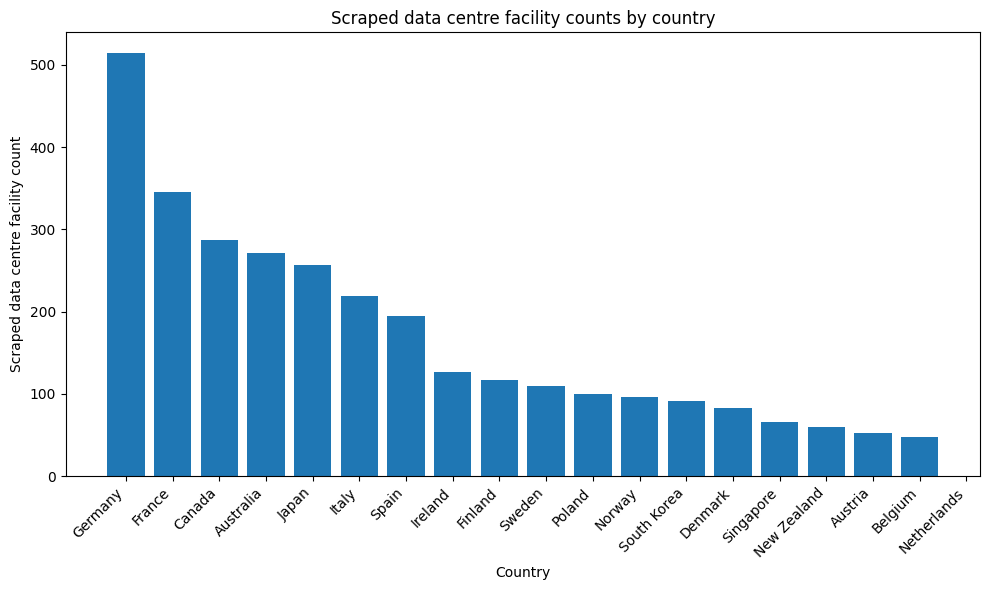

In [12]:
import matplotlib.pyplot as plt

plot_df = dc_rank.sort_values("dc_facility_count", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.bar(plot_df["country"], plot_df["dc_facility_count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Country")
plt.ylabel("Scraped data centre facility count")
plt.title("Scraped data centre facility counts by country")
plt.tight_layout()
plt.savefig("outputs/fig_scraped_datacentre_counts.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
top_dc = dc_rank.head(5)
bottom_dc = dc_rank.tail(5)

print("Top 5 countries by scraped facility count:")
print(top_dc.to_string(index=False))

print("\nBottom 5 countries by scraped facility count:")
print(bottom_dc.to_string(index=False))

Top 5 countries by scraped facility count:
  country iso3  dc_facility_count  dc_facility_count_log  dc_rank
  Germany  DEU              514.0               6.244167        1
   France  FRA              345.0               5.846439        2
   Canada  CAN              287.0               5.662960        3
Australia  AUS              272.0               5.609472        4
    Japan  JPN              257.0               5.552960        5

Bottom 5 countries by scraped facility count:
      country iso3  dc_facility_count  dc_facility_count_log  dc_rank
  New Zealand  NZL               60.0               4.110874       16
      Austria  AUT               53.0               3.988984       17
      Belgium  BEL               48.0               3.891820       18
  Netherlands  NLD                NaN                    NaN       19
United States  USA                NaN                    NaN       20
